# Exploratory Data Analysis

## Import

In [31]:
from titanic.data import load_processed_data, load_train, load_test
from titanic.eda import stats, describe_numeric
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 100)

# graphs
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
import seaborn as sns

df = load_processed_data()
df_train = load_train()
df_test = load_test()

In [33]:
from titanic.selection import select_model_features
from titanic.preprocessing import preprocess_train_test

# sélection des features du modèle
df_model = select_model_features(
    df,
    feature_set="base"
)

features = [
    col
    for col in df_model.columns
    if col != "Survived"
]

# preprocessing identique au pipeline
X_train, y_train, X_test, preprocessor = preprocess_train_test(
    df_model,
    features=features
)

print(X_train.shape)
print(y_train.shape)

(891, 31)
(891,)


In [10]:
display(stats(df).loc[["Survived"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,float64,891,418 (32%),2,0.0,549,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0


<Axes: xlabel='Survived', ylabel='count'>

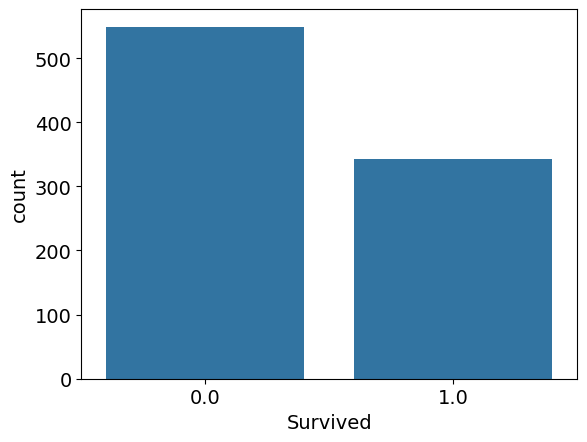

In [11]:
sns.countplot(
    data=df[df["Survived"].notna()],
    x="Survived"
)

In [12]:
pd.crosstab(
    df["SexIsMale"],
    df["Survived"],
    normalize="index"
)

Survived,0.0,1.0
SexIsMale,,
0,0.257962,0.742038
1,0.811092,0.188908


« Les femmes et les enfants d’abord ».  
L’adage semble être bien respecté puisque la probabilité de survivre en tant qu’homme est de moins de 20%, tandis qu’elle est à 74% pour les femmes.  
Donc variable très importantes.

In [13]:
pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
)

Survived,0.0,1.0
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Les classes des passagers sont également très important.  
Plus la classe est haute (1), plus les chances de survie augmentent.  
Et inversement.

In [14]:
pd.crosstab(
    df["Title"],
    df["Survived"],
    normalize="index"
)

Survived,0.0,1.0
Title,,
Master,0.425000,0.575000
Miss,0.298913,0.701087
Mr,0.838290,0.161710
Mrs,0.201550,0.798450


- Les titres ont également de l’importance, mais principalement pour Miss, Mr et Mrs.
- Master, qui semblait représenter les adolescents hommes, est presque équilibré …

<Axes: xlabel='Survived', ylabel='AgeETR'>

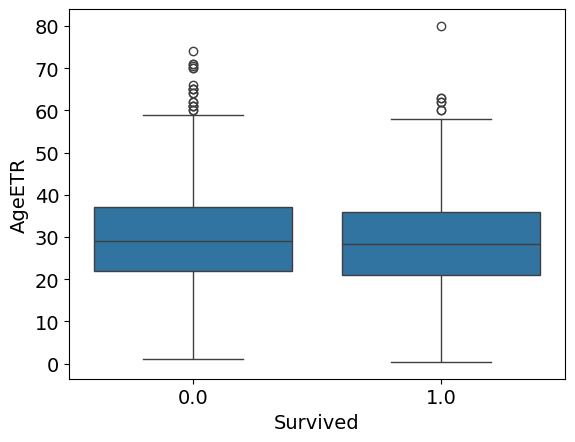

In [16]:
sns.boxplot(
    data=df,
    x="Survived",
    y="AgeETR"
)

<Axes: xlabel='Survived', ylabel='FarePerPerson_log1p'>

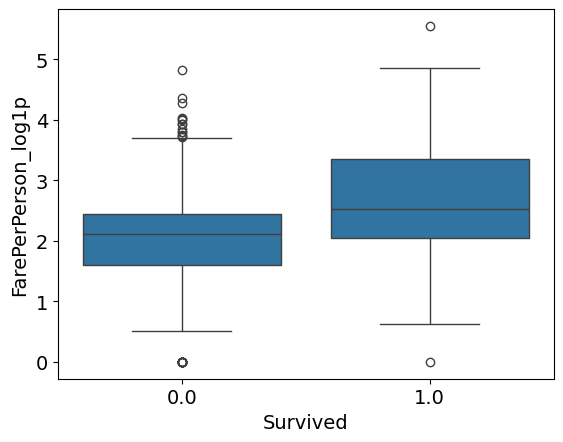

In [17]:
sns.boxplot(
    data=df,
    x="Survived",
    y="FarePerPerson_log1p"
)

<Axes: xlabel='Survived', ylabel='CabinNumber'>

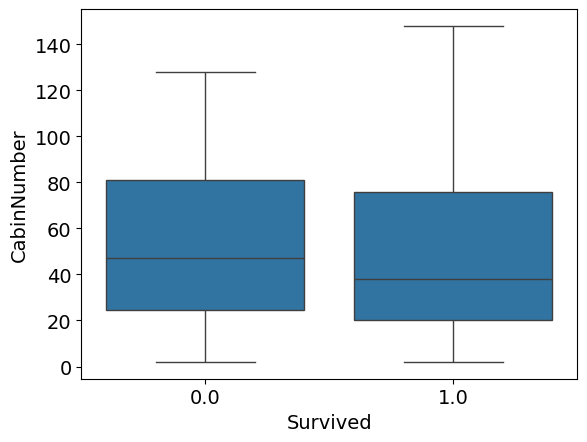

In [18]:
sns.boxplot(
    data=df,
    x="Survived",
    y="CabinNumber"
)

<Axes: xlabel='Survived', ylabel='FamilySize'>

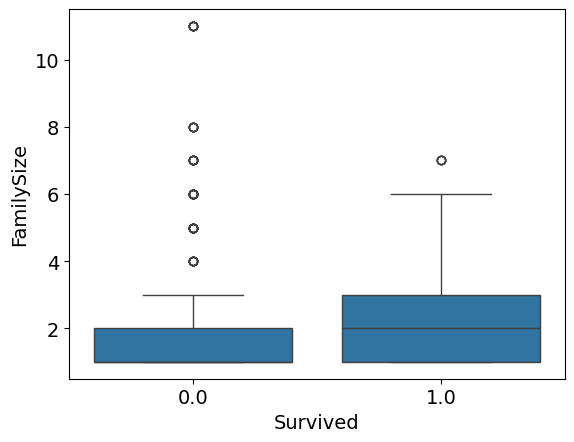

In [19]:
sns.boxplot(
    data=df,
    x="Survived",
    y="FamilySize"
)

<Axes: xlabel='Survived', ylabel='GroupSize'>

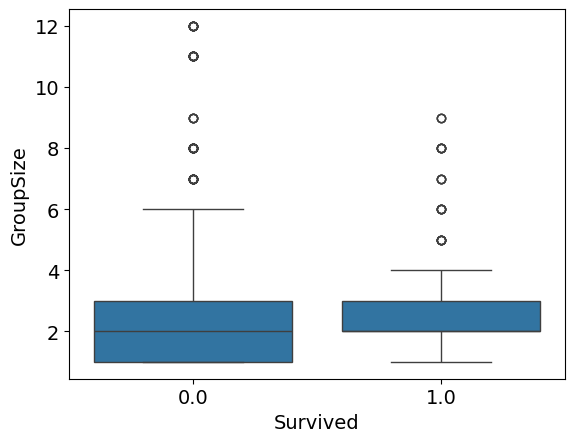

In [20]:
sns.boxplot(
    data=df,
    x="Survived",
    y="GroupSize"
)

<Axes: xlabel='AgeETR', ylabel='Density'>

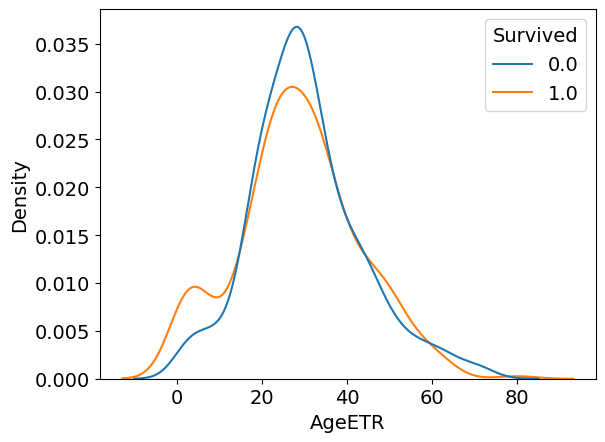

In [25]:
sns.kdeplot(
    data=df,
    x="AgeETR",
    hue="Survived",
    common_norm=False
)

<Axes: xlabel='FarePerPerson_log1p', ylabel='Density'>

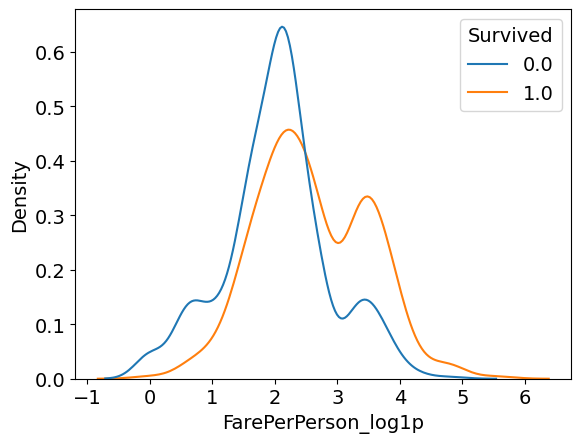

In [26]:
sns.kdeplot(
    data=df,
    x="FarePerPerson_log1p",
    hue="Survived",
    common_norm=False
)

## Corrélations

<Axes: >

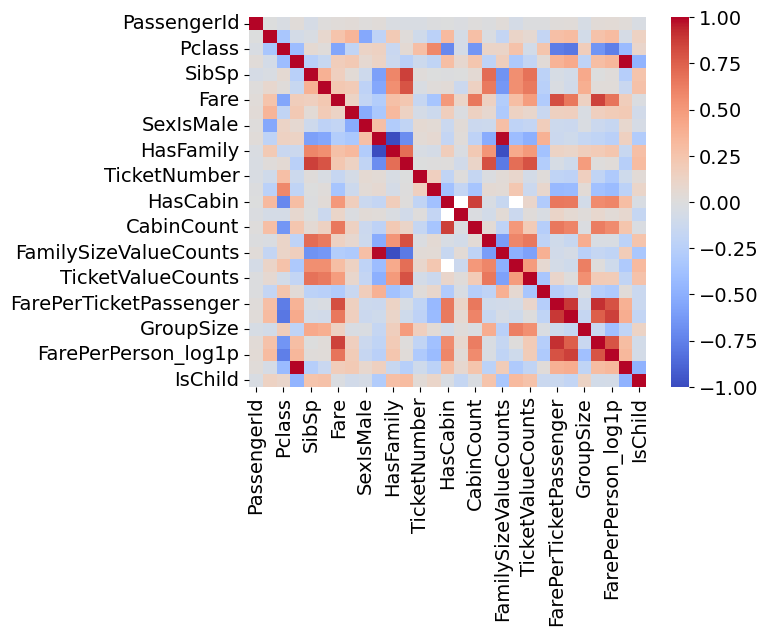

In [27]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

In [45]:
corr["Survived"] \
    .sort_values(ascending=False)

Survived                        1.000000
HasNickname                     0.346496
HasCabin                        0.316912
FarePerPerson_log1p             0.307913
FarePerTicketPassenger_log1p    0.306219
FarePerTicketPassenger          0.288337
CabinCount                      0.283704
FarePerPerson                   0.259621
Fare                            0.257307
HasFamily                       0.203367
IsChild                         0.138047
CabinValueCounts                0.114854
Parch                           0.081629
TicketValueCounts               0.064962
FamilySize                      0.016639
PassengerId                    -0.005007
SurnameValueCounts             -0.025524
SibSp                          -0.035322
AgeETR                         -0.061691
CabinNumber                    -0.063747
Age                            -0.077221
GroupSize                      -0.083525
TicketNumber                   -0.095605
FareValueCounts                -0.176521
FamilySizeValueC

### Features importance

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
3,num__AgeETR,0.190678
6,num__FarePerPerson_log1p,0.189526
10,cat__Title_Mr,0.122809
2,num__SexIsMale,0.088058
0,num__Pclass,0.054366
9,cat__Title_Miss,0.040671
1,num__HasNickname,0.038054
4,num__SibSp,0.036338
11,cat__Title_Mrs,0.032607
7,num__HasCabin,0.024798
